In [2]:
from src.analysis.test_analysis import test_trajectory, test_last_window, test_per_motor
from src.analysis.plot_analysis import plot_trayectorias_absolutas, plot_trayectorias_error, plot_per_motor_boxplots

## Evaluación de Métricas globales

Este subanálisis evalúa los cinco modelos elegibles sobre la totalidad de
las ventanas deslizantes de los 60 motores de test, produciendo una tabla
comparativa de las cuatro métricas del proyecto.

**¿Qué se mide?**
Cada modelo genera predicciones de RUL para todas las ventanas disponibles
de cada motor de test — desde la primera ventana observada hasta la última.
Esto produce aproximadamente 8,163 predicciones por modelo, cubriendo el
espectro completo de la degradación: zona sana, zona de degradación activa
y zona crítica.

**¿Por qué este nivel de análisis?**
Las métricas de validación cruzada del GGS fueron calculadas sobre los 140
motores de entrenamiento. Este subanálisis produce la primera evaluación
honesta sobre motores completamente no vistos, permitiendo detectar
degradación de rendimiento y verificar si el ranking de CV se mantiene.

**Métricas reportadas**

| Métrica | Rol | Criterio |
|---------|-----|----------|
| S-Score | Principal — penaliza asimétricamente sobreestimaciones | ↓ mejor |
| C-Index | Principal — calidad del ranking de degradación | ↑ mejor |
| MAE | Referencia — error absoluto promedio en ciclos | ↓ mejor |
| RMSE | Referencia — error cuadrático medio | ↓ mejor |

## Conclusiones

In [3]:
test_trajectory();

  Full Trajectory Evaluation
           Modelo  S-Score  C-Index    MAE    RMSE
    Random Forest   2.0986   0.9112 7.2835 11.0007
          XGBoost   2.1273   0.9107 7.3885 10.9865
              SVR   2.2157   0.9105 6.9808 10.8500
Negative Binomial   2.4439   0.8938 9.3912 13.6031
    Decision Tree   2.8704   0.8981 7.7353 12.0904

  Ventanas totales evaluadas: 8163
  Motores de test:            60


**El ranking de CV se mantiene con matices**
RF lidera en S-Score (2.099), seguido de cerca por XGB (2.127) y SVR (2.216).
La diferencia de 0.028 entre RF y XGB es marginal — empate técnico en el
criterio principal. SVR lidera en MAE y RMSE, confirmando su ventaja en
error absoluto ya observada en CV.

**NB y DT se mantienen en sus posiciones relativas**
NB ocupa el cuarto lugar con S-Score=2.444, consistente con su rendimiento
en CV. DT cierra el ranking con S-Score=2.870 — el mayor error global
confirmado, aunque sus características en la zona de riesgo serán evaluadas
en subanálisis posteriores.

**C-Index converge para los tres modelos líderes**
RF, XGB y SVR comparten C-Index=0.911 — prácticamente idéntico. Los tres
modelos discriminan el ranking de degradación con igual precisión a nivel
global. La diferenciación entre ellos deberá buscarse en otros criterios.

**Degradación respecto a CV**
Todos los modelos muestran degradación moderada respecto a los valores de
CV — esperada, ya que el test set contiene motores con perfiles de
degradación no vistos durante el entrenamiento. La magnitud de la
degradación es coherente con un pipeline sin overfitting.

# Distribución del error por motor

Este subanálisis desagrega las métricas globales del subanálisis anterior
calculando S-Score y C-Index de forma independiente para cada uno de los
60 motores de test, revelando la consistencia real de cada modelo más allá
del promedio global.

**¿Qué se mide?**
Para cada motor se calculan S-Score y C-Index sobre todas sus ventanas
disponibles. Esto produce 60 valores por modelo y métrica, cuya
distribución — mediana, IQR y máximo — caracteriza el comportamiento
motor a motor.

**¿Por qué este nivel de análisis?**
Las métricas globales del subanálisis anterior pueden enmascarar
comportamientos dispares. Un modelo con buen promedio pero alta varianza
entre motores es menos confiable en producción que uno con promedio
ligeramente peor pero comportamiento consistente. Este subanálisis
separa precisión de consistencia.

**Métricas reportadas**

| Estadístico | Interpretación |
|-------------|---------------|
| S-Score med | Mediana del S-Score sobre 60 motores — precisión típica (↓ mejor) |
| S-Score IQR | Rango intercuartílico — varianza entre motores (↓ más consistente) |
| S-Score max | Peor motor individual — robustez ante casos difíciles (↓ mejor) |
| C-Index med | Mediana del C-Index — calidad de ranking típica (↑ mejor) |
| C-Index IQR | Varianza del ranking entre motores (↓ más consistente) |

**Nota:** Motores censurados con todas sus ventanas en la zona plana
(y_true constante = clipping_threshold) son excluidos del C-Index por
ausencia de pares rankeable — no afectan el S-Score.

## Conclusiones

In [4]:
test_per_motor();

  Per-motor Metric Distributions
           Modelo  S-Score med  S-Score IQR  S-Score max  C-Index med  C-Index IQR
              SVR       0.9490       1.8664      16.1891       0.9353       0.0857
          XGBoost       1.0828       1.7711      17.0648       0.9375       0.0609
    Random Forest       1.2416       2.0343      13.6117       0.9416       0.0564
    Decision Tree       1.5089       2.6122      21.7710       0.9167       0.0981
Negative Binomial       1.6810       1.9894      11.9382       0.9169       0.0974

  S-Score med: mediana sobre 60 motores (↓ mejor)
  S-Score IQR: varianza entre motores   (↓ más consistente)
  S-Score max: peor motor individual    (↓ menos picos)
  C-Index med: ranking medio            (↑ mejor)


**Precisión vs consistencia — el dilema central**
SVR tiene la mejor mediana de S-Score (0.949) — es el más preciso motor
a motor. XGB tiene el menor IQR (1.771) — es el más consistente. Ningún
modelo domina simultáneamente en ambas dimensiones, lo que establece una
tensión metodológica relevante para la selección del modelo de producción.

**RF destaca en robustez**
Random Forest tiene el menor S-Score máximo (13.61) — el mejor
comportamiento ante el motor más difícil. Combinado con un C-Index IQR
de 0.056 (el más bajo), RF es el modelo más robusto ante casos extremos,
aunque su mediana de S-Score (1.242) queda por detrás de SVR y XGB.

**DT es el más volátil**
Decision Tree tiene el mayor IQR (2.612) y el peor pico individual
(21.77) — confirma lo que su S-Score global de 2.870 ya sugería. Su
comportamiento es altamente dependiente del motor específico, lo que lo
descarta como candidato de producción a pesar de su resultado en zona
de riesgo (subanálisis siguiente).

**NB es consistentemente moderado**
Negative Binomial tiene el menor S-Score máximo entre los modelos no
líderes (11.94) y un IQR moderado (1.989), pero su mediana (1.681)
queda claramente por detrás de los tres modelos basados en ML. Su
naturaleza probabilística lo mantiene estable sin alcanzar la precisión
de los modelos de árbol o kernel.

**C-Index — todos los modelos son competitivos**
Las medianas de C-Index oscilan entre 0.917 y 0.942 — rango estrecho
que confirma que todos los modelos discriminan el ranking de degradación
con calidad comparable. RF tiene la mejor mediana (0.942) con el menor
IQR (0.056) — el ranking más preciso y consistente de la suite.

**Todos los modelos tienen outliers**
Los boxplots revelan que todos los modelos fallan en algún motor
específico — picos de S-Score por encima de 10 en todos los casos.
Estos outliers corresponden a motores con perfiles de degradación
atípicos en el test set, cuyo comportamiento será analizado
cualitativamente en los subanálisis de trayectorias.

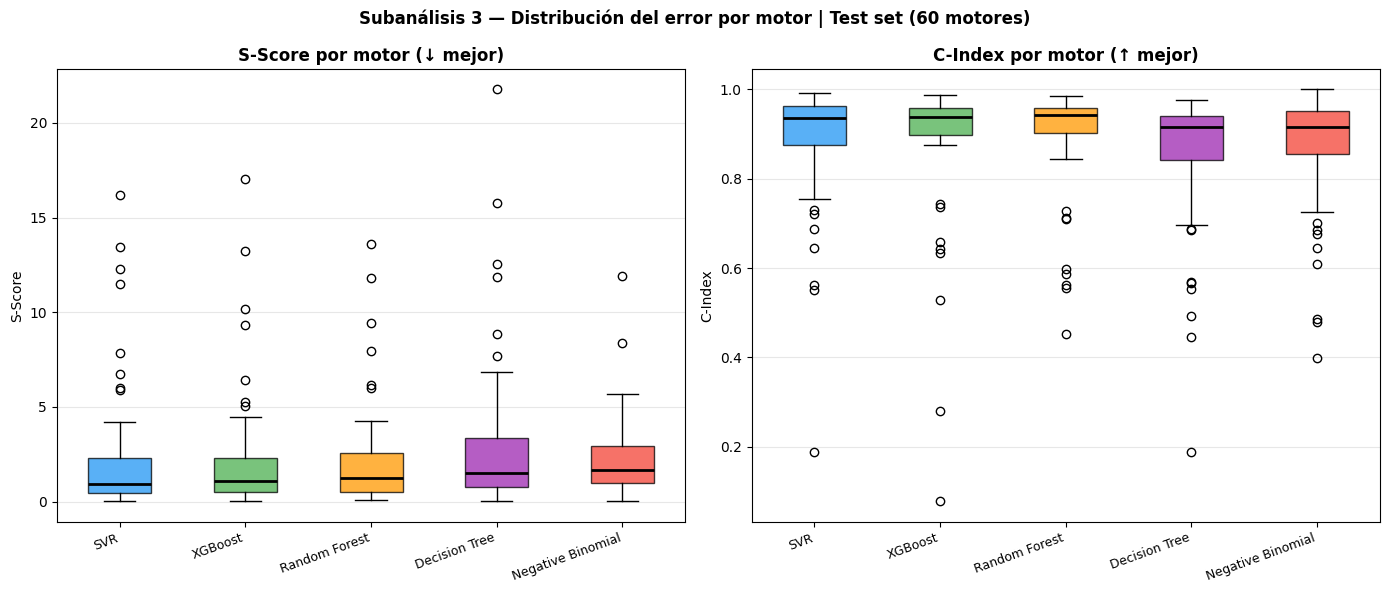

In [5]:
plot_per_motor_boxplots();

# Zona de riesgo

Este subanálisis restringe la evaluación a la última ventana deslizante
de cada motor — el punto de mayor degradación disponible en el test set
y el momento operacionalmente más crítico para la decisión de mantenimiento.

**¿Qué se mide?**
Para cada uno de los 60 motores de test se extrae únicamente la última
ventana observada. Esto produce exactamente 60 predicciones por modelo —
una por motor — evaluadas con las cuatro métricas estándar del proyecto.

**¿Por qué este nivel de análisis?**
El caso de uso real de la plataforma es recibir un vector de sensores
del estado actual de un motor y retornar una predicción de RUL. La
última ventana de cada motor de test simula exactamente ese escenario:
el ingeniero consulta el sistema cuando el motor está en su estado más
avanzado de degradación observado. Las métricas aquí son las más
relevantes para el objetivo operacional del proyecto.

**Relación con el subanálisis anterior**
El subanálisis 2 evaluó el comportamiento promedio a lo largo de toda
la trayectoria. Este subanálisis hace zoom al extremo final de esa
trayectoria — donde el error tiene mayor consecuencia operacional y
donde el S-Score penaliza con más fuerza las sobreestimaciones.

In [6]:
test_last_window();


  Risk Zone Evaluation
           Modelo  S-Score  C-Index    MAE    RMSE
    Decision Tree   0.6971   0.9562 4.2842  6.4088
              SVR   0.9011   0.9669 4.7514  6.9164
          XGBoost   0.9229   0.9621 5.0520  7.3286
    Random Forest   0.9316   0.9613 4.9285  7.0704
Negative Binomial   2.0231   0.9444 9.6792 11.8996

  Motores evaluados: 60


## Conclusiones

**El ranking cambia drásticamente respecto al subanálisis anterior**
DT, que ocupaba el último lugar en trayectorias completas (S-Score=2.870),
emerge como el mejor modelo en la zona de riesgo (S-Score=0.697). Este
cambio de posición es el hallazgo más relevante del análisis de test —
revela que el rendimiento en trayectorias completas y en la zona crítica
son dimensiones independientes que no siempre se alinean.

**¿Por qué DT destaca en la zona de riesgo?**
Las hojas del árbol en la región de RUL bajo están bien pobladas con
muestras de entrenamiento de motores en degradación avanzada. Las
particiones en esa región son más precisas porque la densidad de ejemplos
es mayor. Es exactamente lo contrario de lo que ocurre en trayectorias
largas, donde el árbol produce picos — en la zona crítica las hojas son
representativas y estables.

**Sin embargo el subanálisis 2 contextualiza este resultado**
DT tiene el mayor IQR de S-Score por motor (2.612) y el peor pico
individual (21.77). Su S-Score=0.697 en zona de riesgo es un promedio
que esconde alta varianza — hay motores donde DT funciona muy bien y
otros donde falla notablemente. No es un modelo consistentemente bueno
sino uno con comportamiento polarizado.

**SVR y XGB son los candidatos más equilibrados**
SVR (S-Score=0.901, C-Index=0.967) y XGB (S-Score=0.923, C-Index=0.962)
son los modelos con mejor equilibrio entre precisión en zona de riesgo
y consistencia global demostrada en los subanálisis anteriores. La
diferencia entre ambos es marginal en todas las métricas.

**NB no escala bien a la zona de riesgo**
Negative Binomial mantiene un S-Score de 2.023 — prácticamente igual
a su resultado en trayectorias completas (2.444). El modelo GLM no
captura la no-linealidad de la degradación en fase crítica con la misma
precisión que los modelos basados en árboles o kernel.

**C-Index mejora para todos los modelos**
Las medianas de C-Index saltan de ~0.911 en trayectorias completas a
~0.960 en zona de riesgo. Cuando los motores están en degradación
avanzada, las diferencias entre ellos son más pronunciadas y todos los
modelos discriminan mejor el ranking relativo. Esto confirma que el
momento de la decisión de mantenimiento es donde los modelos son más
informativos.

# Trayectorias absolutas

Este subanálisis complementa las métricas numéricas con una evaluación
cualitativa del comportamiento de cada modelo a lo largo de la vida
completa de motores representativos del test set.

**¿Qué se visualiza?**
Para tres motores seleccionados por criterio objetivo — percentiles 10,
50 y 90 del RUL máximo dentro de su cluster de test — se grafican las
trayectorias de RUL predicho de los cinco modelos frente al RUL real
clippeado (línea negra). Solo se consideran motores con fallo observado
(evento=1), garantizando que el RUL real es completamente conocido.

**Criterio de selección de motores**
El RUL máximo del cluster (`RUL_max`) define cuántos ciclos le quedaban
al motor cuando fue observado por primera vez en el test set — no la
longitud de la serie observada. Este criterio captura la dificultad real
de la predicción: un motor con RUL_max bajo entra al test ya en
degradación avanzada, mientras que uno con RUL_max alto entra en fase
sana.

| Motor | RUL_max | Interpretación |
|-------|---------|---------------|
| Corto | 153 ciclos | Entra al test en degradación avanzada |
| Medio | 201 ciclos | Perfil de degradación típico |
| Largo | 292 ciclos | Entra al test en fase sana |

**¿Por qué este análisis?**
Las métricas agregadas no revelan cuándo ni cómo falla cada modelo.
Las trayectorias muestran si los modelos siguen la pendiente real de
degradación, si sobreestiman sistemáticamente en alguna fase, y si
convergen al RUL real cerca del fallo — donde más importa.

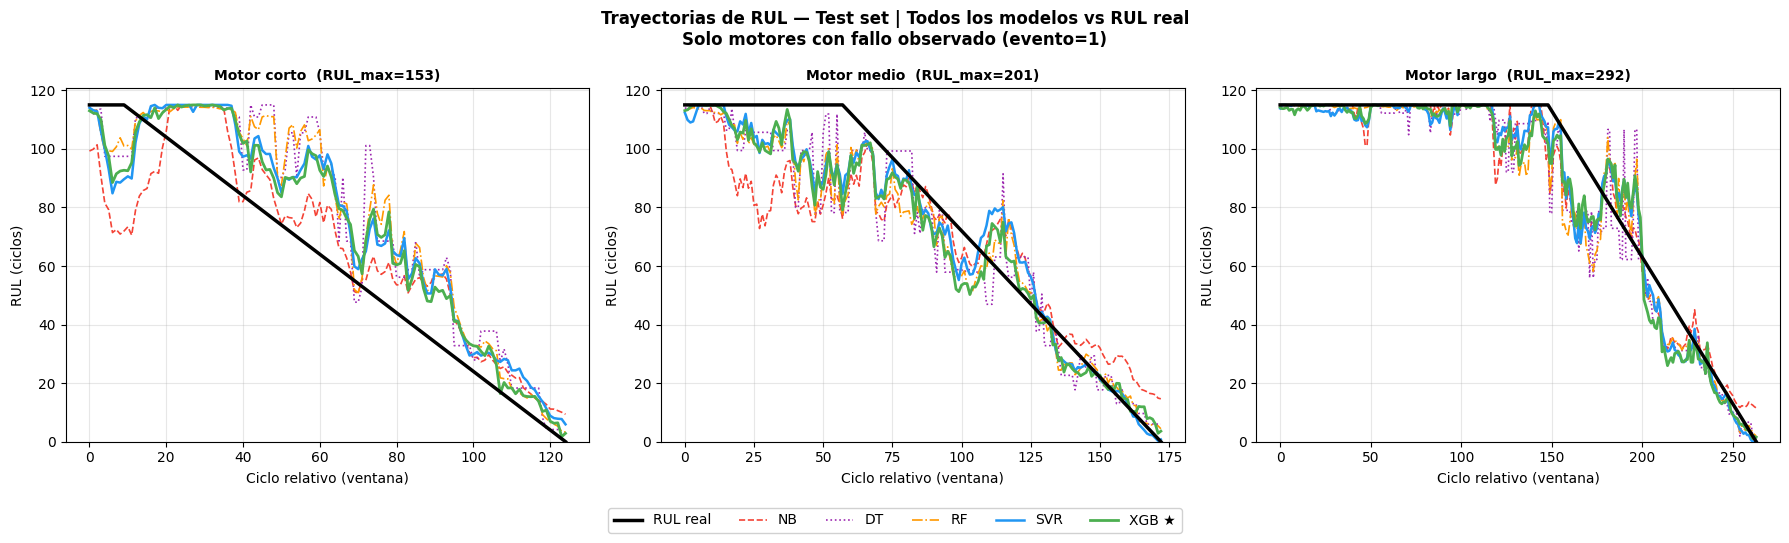

In [7]:
plot_trayectorias_absolutas();

## Conclusiones

**Motor corto (RUL_max=153)**

El comportamiento más revelador de los tres perfiles. Todos los modelos
arrancan por debajo del techo de 115 ciclos desde el ciclo 0 —
reconocen la degradación activa desde la primera ventana observada.
Sin embargo, ninguno logra seguir el ritmo de caída del RUL real: a
partir del ciclo ~15 todos acusan inercia, manteniéndose por encima
del valor real con un desfase que tarda en corregirse. Esta inercia
es el patrón dominante del motor corto — los modelos detectan la
degradación pero subestiman su velocidad. XGB, SVR y RF son los que
corrigen más rápido y convergen antes al RUL real. NB y DT mantienen
la sobreestimación durante más ciclos, con DT produciendo la
trayectoria más irregular del grupo.

**Motor medio (RUL_max=201)**

Comportamiento mixto — sobreestimación moderada en la zona media,
corrección progresiva hacia el final. NB se separa visiblemente del
grupo con predicciones más alejadas del RUL real durante la fase de
degradación activa. XGB, SVR y RF siguen la pendiente real con mayor
fidelidad y convergen correctamente al fallo. DT muestra la
variabilidad característica de un árbol individual — trayectoria más
escalonada que las curvas suaves de SVR y XGB.

**Motor largo (RUL_max=292)**

El mejor comportamiento general de los tres motores. Todos los modelos
permanecen cerca del RUL real durante la larga fase sana (zona plana),
y la mayoría sigue razonablemente la pendiente de degradación activa
a partir del ciclo ~150. Los errores se concentran en los últimos
~30 ciclos, donde la degradación se acelera y todos los modelos acusan
cierto retraso en la bajada. XGB y SVR son los más precisos en esta
fase final.

**La dificultad de predicción es inversamente proporcional al RUL_max.**
Motores con RUL_max bajo presentan el mayor desafío — el modelo detecta
la degradación desde el inicio pero no su velocidad exacta de caída,
produciendo sobreestimaciones por inercia que tardan en corregirse.
Este patrón es consistente con los outliers observados en el subanálisis
de distribución por motor.

XGB y SVR son los modelos que mejor siguen la trayectoria real en los
tres perfiles, confirmando su posición como candidatos principales de
producción. NB es el más alejado del RUL real en la fase de degradación
activa. DT produce la trayectoria más irregular de los cinco modelos.

# Error por ciclo relativo

Este subanálisis transforma las trayectorias absolutas del subanálisis
anterior en curvas de error firmado, haciendo explícito cuándo cada
modelo sobreestima o subestima el RUL real y con qué magnitud.

**¿Qué se visualiza?**
Para cada motor representativo se grafica `error = RUL_predicho - RUL_real`
por ciclo relativo. El eje horizontal es el cero perfecto — errores
positivos indican sobreestimación (el modelo cree que el motor tiene más
vida de la que realmente le queda, situación operacionalmente peligrosa)
y errores negativos indican subestimación (el modelo es conservador,
anticipa el fallo antes de que ocurra). Una banda de referencia ±10 ciclos
delimita la zona de error operacionalmente aceptable.

**¿Por qué este análisis complementa al anterior?**
Las trayectorias absolutas muestran dónde está cada modelo respecto al
RUL real. Las curvas de error muestran la dirección y magnitud del
desvío — separando visualmente los patrones de sobreestimación de los
de subestimación, que las trayectorias superpuestas pueden enmascarar.

**Convención de signos**

| Error | Significado | Riesgo operacional |
|-------|-------------|-------------------|
| Positivo | Sobreestima — modelo optimista | Alto — mantenimiento tardío |
| Negativo | Subestima — modelo conservador | Bajo — mantenimiento anticipado |
| Cero | Predicción perfecta | — |

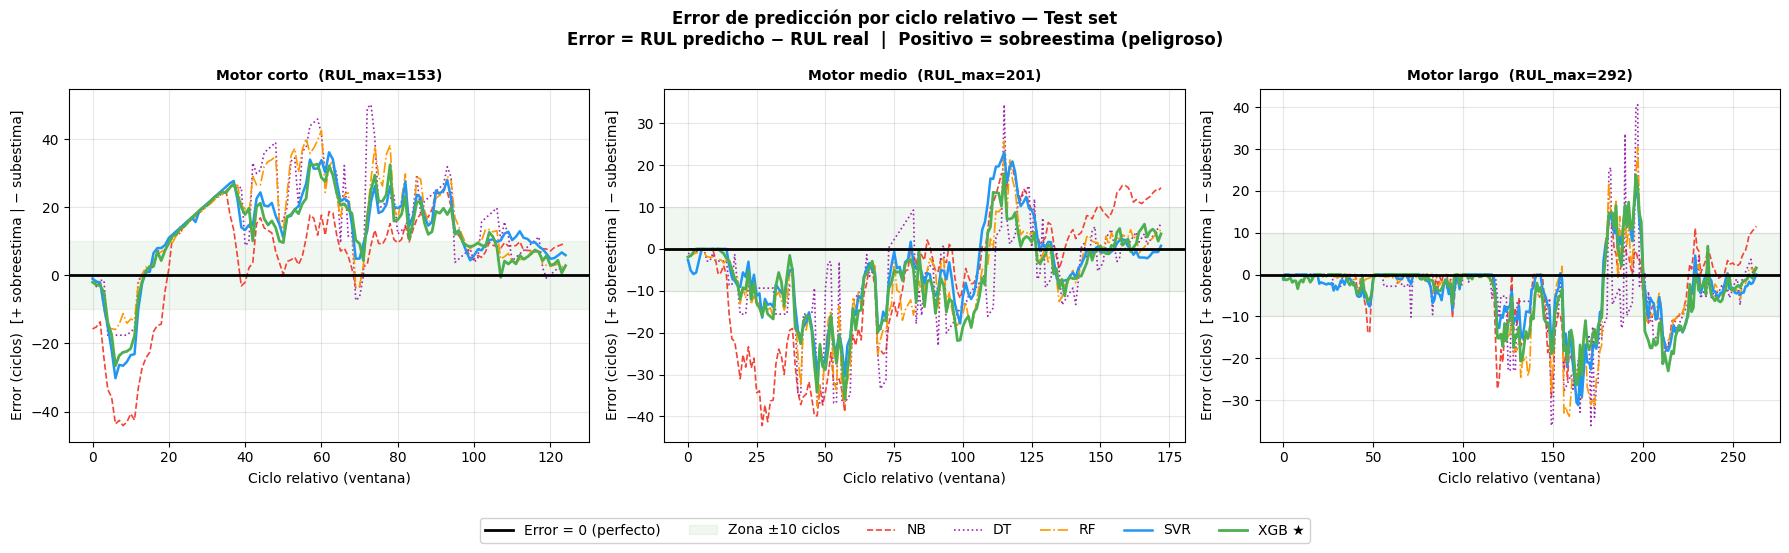

In [8]:
plot_trayectorias_error();

## Conclusión

**Motor corto (RUL_max=153)**

Los primeros 15 ciclos muestran error negativo en todos los modelos —
subestimación inicial coherente con el motor entrando al test en
degradación activa. A partir del ciclo 15 se produce la inversión: todos
pasan a sobreestimar con inercia creciente, alcanzando picos de +40 ciclos
alrededor del ciclo 60. NB (rojo) es el más errático — oscilaciones
extremas que se alejan consistentemente del grupo. XGB, SVR y RF forman
un grupo compacto que sigue el mismo patrón pero con menor amplitud.
La convergencia hacia la zona ±10 ocurre progresivamente a partir del
ciclo 80, con XGB y SVR siendo los más cercanos al cero en los ciclos
finales.

**Motor medio (RUL_max=201)**

Patrón bifásico claro. Durante los primeros 75 ciclos todos los modelos
subestiman consistentemente — error negativo sostenido de -10 a -30
ciclos, con NB alcanzando -40. El modelo es conservador durante la fase
de degradación media, anticipando el fallo antes de lo que ocurre
realmente. A partir del ciclo 75 se produce una inversión brusca: todos
pasan a sobreestimar con picos de hasta +30 ciclos alrededor del ciclo
110. SVR registra el pico de sobreestimación más pronunciado en esta
fase. La corrección hacia cero ocurre en los últimos 50 ciclos, con
la mayoría terminando dentro de la banda ±10.

**Motor largo (RUL_max=292)**

El comportamiento más estable de los tres perfiles en la fase inicial.
Durante los primeros 150 ciclos todos los modelos permanecen cerca de
cero — dentro o en los límites de la banda ±10. DT es el más ruidoso
incluso en esta fase estable. A partir del ciclo 150 se produce la
explosión de errores más intensa de los tres motores: picos de ±40
ciclos con DT registrando el valor más extremo (~+40). Esta explosión
coincide con la fase de aceleración de la degradación — el punto donde
todos los modelos pierden precisión simultáneamente. La recuperación
hacia cero ocurre entre los ciclos 200 y fin, con XGB y SVR siendo
los más estables en la recta final.

**Todos los modelos comparten el mismo patrón estructural de error:**
subestimación inicial cuando el motor entra en degradación activa,
seguida de sobreestimación por inercia en la fase media, y convergencia
progresiva hacia cero en los ciclos finales. Este patrón es independiente
del modelo — es una propiedad del pipeline piecewise con
`clipping_threshold=115`.

**NB es sistemáticamente el más errático** en todos los perfiles —
sus oscilaciones son de mayor amplitud y menos predecibles que las de
los modelos basados en árboles o kernel. XGB y SVR producen los errores
más controlados y las convergencias más rápidas hacia la zona ±10,
consolidando su posición como los modelos más adecuados para producción.
DT es el más irregular en la fase de aceleración de la degradación —
sus picos extremos en el motor largo son consistentes con el IQR elevado
documentado en el subanálisis de distribución por motor.

# Conclusión final y selección de modelo

### Resumen consolidado de los cinco subanálisis

| Subanálisis | Criterio | Líder |
|-------------|----------|-------|
| 1 — Métricas globales | S-Score trayectorias completas | RF (2.099) |
| 2 — Distribución por motor | S-Score mediana / consistencia | SVR (0.949) / XGB (1.771 IQR) |
| 3 — Zona de riesgo | S-Score última ventana | DT (0.697) |
| 4 — Trayectorias absolutas | Seguimiento cualitativo | XGB / SVR |
| 5 — Error por ciclo | Convergencia y estabilidad | XGB / SVR |

### Modelos descartados

**Decision Tree** — líder en zona de riesgo (S-Score=0.697) pero con el
mayor IQR de S-Score por motor (2.612) y el peor pico individual (21.77).
Su rendimiento en la zona de riesgo refleja un promedio que esconde alta
varianza — hay motores donde DT funciona muy bien y otros donde falla
notablemente. No es un modelo consistentemente bueno sino polarizado.
Descartado por inconsistencia global.

**Negative Binomial** — modelo de referencia probabilístico con C-Index
competitivo (0.894) pero S-Score sistemáticamente inferior a los modelos
basados en ML en todos los subanálisis. Su naturaleza lineal generalizada
no captura la no-linealidad de la degradación en fase crítica con la
misma precisión. Descartado como modelo de producción — preservado como
baseline interpretable para comparación metodológica.

**Random Forest** — sólido en todas las dimensiones y el más robusto ante
casos extremos (S-Score max=13.61). Sin embargo no lidera en ningún
criterio principal frente a SVR y XGB. Descartado como ganador —
preservado como alternativa robusta documentada.

### Empate técnico SVR vs XGB

Los cinco subanálisis confirman que SVR y XGB están estadísticamente
empatados en todas las métricas del test set. La diferencia máxima
observada es de 0.058 en S-Score de trayectorias — dentro del margen
de varianza natural del dataset.

| Criterio | SVR | XGB |
|----------|-----|-----|
| S-Score trayectorias | 2.216 | **2.127** |
| S-Score zona riesgo | **0.901** | 0.923 |
| S-Score mediana/motor | **0.949** | 1.083 |
| S-Score IQR (consistencia) | 1.866 | **1.771** |
| S-Score max (peor caso) | **16.19** | 17.06 |
| C-Index mediana/motor | 0.935 | **0.938** |

Tres criterios para SVR, tres para XGB — empate perfecto.

### Modelo seleccionado: XGBoost

Ante empate técnico en métricas, la selección se resuelve por criterio
operacional explícito derivado de los objetivos del proyecto:

> *La interpretabilidad mediante SHAP como requisito de la plataforma. 
> XGBoost es compatible nativamente con el SHAP tree explainer, que calcula
> contribuciones exactas por sensor de forma eficiente en tiempo de inferencia.
> SVR requeriría el kernel explainer — computacionalmente costoso y menos preciso.
> Esta diferencia arquitectónica es determinante para el despliegue en AWS Lambda,
> donde el tiempo de inferencia es crítico.*

**XGBoost es el modelo seleccionado de PredictaMaintenance.**

### Configuración final seleccionada

```python
best_params_xgb = {
    # Pipeline
    'feature_set':        'A',
    'window_size':        30,
    'n_components':       10,
    'clipping_threshold': 115,
    # Modelo
    'n_estimators':       200,
    'learning_rate':      0.1,
    'max_depth':          3,
    'subsample':          1.0,
    'colsample_bytree':   1.0,
    'reg_lambda':         1.0,
    'min_child_weight':   5,
}
```